# Converting a mesh between formats with meshio++

meshio++ converts one in-memory `Mesh` to any of its 35+ formats. Here we
take the bracket geometry from `example.msh` and write it to several
formats, compare the resulting file sizes, and verify the round trip.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

import meshioplusplus as mp

EXAMPLE = os.path.join(os.path.dirname(os.getcwd()), 'example.msh')
if not os.path.exists(EXAMPLE):
    EXAMPLE = os.path.join('..', 'example.msh')  # when run from example/python/ with a different cwd

src = mp.read(EXAMPLE)
# Keep the portable geometry (surface triangles + solid tetrahedra); the
# original file also carries per-entity vertex/line groups and gmsh tags.
tri = np.concatenate([cb.data for cb in src.cells if cb.type == 'triangle'])
tet = np.concatenate([cb.data for cb in src.cells if cb.type == 'tetra'])
mesh = mp.Mesh(src.points, [('triangle', tri), ('tetra', tet)])
print(f'{len(mesh.points):,} points, {len(tri):,} triangles, {len(tet):,} tetrahedra')


52,282 points, 58,394 triangles, 235,014 tetrahedra


## Convert to several formats

In [2]:
tmpdir = tempfile.mkdtemp()

# (label, filename, write kwargs)
targets = [
    ('vtu (ascii)',       'mesh_ascii.vtu', dict(binary=False)),
    ('vtu (binary+zlib)', 'mesh.vtu',       dict(binary=True)),
    ('vtk (binary)',      'mesh.vtk',       dict(binary=True)),
    ('xdmf',              'mesh.xdmf',      {}),
    ('gmsh (binary)',     'mesh.msh',       dict(binary=True, file_format='gmsh')),
    ('ply (binary)',      'mesh.ply',       dict(binary=True)),
]

def total_size(path):
    # XDMF writes a companion .h5; count the sidecar too.
    size = os.path.getsize(path)
    h5 = os.path.splitext(path)[0] + '.h5'
    if path.endswith('.xdmf') and os.path.exists(h5):
        size += os.path.getsize(h5)
    return size

results = []
for label, fn, kw in targets:
    path = os.path.join(tmpdir, fn)
    mesh.write(path, **kw)
    mb = total_size(path) / 1e6
    results.append((label, path, kw, mb))
    print(f'{label:20s} {mb:7.2f} MB')

vtu (ascii)            12.31 MB
vtu (binary+zlib)       4.77 MB
vtk (binary)           13.70 MB


xdmf                    3.45 MB
gmsh (binary)          12.94 MB
ply (binary)            1.46 MB


meshio warning [ply.cpp:404] PLY: writing the extracted skin of the volume cells; 1 pre-existing non-volume cell block(s) dropped (pass skin=false for the legacy behavior).


## Compare file sizes

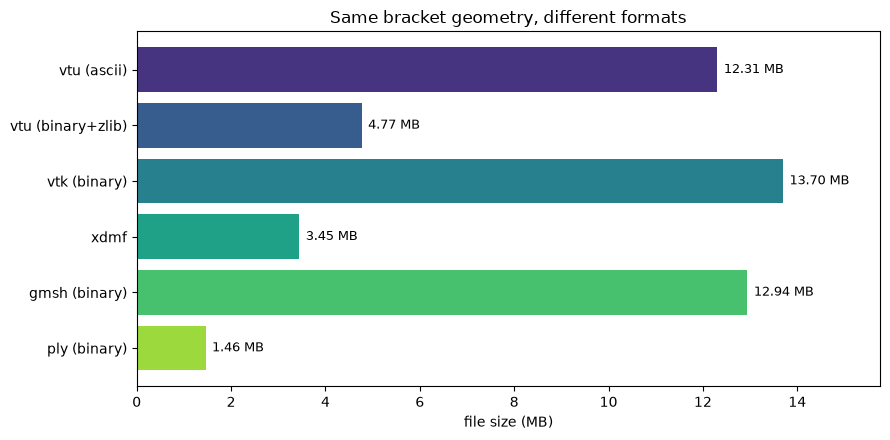

In [3]:
labels = [r[0] for r in results]
sizes = [r[3] for r in results]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(labels)))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(labels, sizes, color=colors)
ax.invert_yaxis()
ax.set_xlabel('file size (MB)')
ax.set_title('Same bracket geometry, different formats')
for bar, mb in zip(bars, sizes):
    ax.text(bar.get_width() + max(sizes) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{mb:.2f} MB', va='center', fontsize=9)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

## Round-trip verification

Read every file back and check the counts survive.

In [4]:
n_pts = len(mesh.points)
n_cells = len(tri) + len(tet)
for label, path, kw, _ in results:
    back = mp.read(path, file_format=kw.get('file_format'))
    bpts = len(back.points)
    bcells = sum(len(cb.data) for cb in back.cells)
    ok = (bpts == n_pts) and (bcells == n_cells)
    status = 'OK ' if ok else 'DIFF'
    print(f'{status} {label:20s} points={bpts:,} cells={bcells:,}')

OK  vtu (ascii)          points=52,282 cells=293,408
OK  vtu (binary+zlib)    points=52,282 cells=293,408
OK  vtk (binary)         points=52,282 cells=293,408


OK  xdmf                 points=52,282 cells=293,408
OK  gmsh (binary)        points=52,282 cells=293,408
DIFF ply (binary)         points=29,151 cells=58,394


Every format round-trips the geometry. For the timing difference between
meshio++ and the original pure-Python meshio, see the
[benchmarks](../benchmark/01_benchmark.ipynb).